In [1]:
!pip install pandas pyodbc

In [2]:
# Task 5 
#Connect Python to SQL Server
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-8PRDP00\\SQLEXPRESS;"
    "DATABASE=master;"
    "Trusted_Connection=yes;"
)

print("SQL Server connection successful!")

SQL Server connection successful!


In [3]:
# Load vw_ChurnData into Pandas
query = "SELECT * FROM ChurnDB.dbo.vw_ChurnData"

df = pd.read_sql(query, conn)

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_100992\4244378930.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,None,DSL,False,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000,False
1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,True,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.500000,False
2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,True,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.150002,True
3,7795-CFOCW,Male,False,False,False,45,False,None,DSL,True,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.750000,False
4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,False,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.649994,True


In [4]:
# Check Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   bool   
 7   MultipleLines     6361 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    5517 non-null   object 
 10  OnlineBackup      5517 non-null   object 
 11  DeviceProtection  5517 non-null   object 
 12  TechSupport       5517 non-null   object 
 13  StreamingTV       5517 non-null   object 
 14  StreamingMovies   5517 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   bool   


In [5]:
# Check Dataset Shape
df.shape

(7043, 21)

In [6]:
#Task 6 — Python Data Cleaning & Feature Preparation
# Check Missing Values
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines        682
InternetService        0
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

In [7]:
# Create Cleaned DataFrame
cleaned_df = df.copy()

In [8]:
# Handle Missing Service Values
cleaned_df["MultipleLines"] = cleaned_df["MultipleLines"].fillna("No phone service")

internet_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

cleaned_df[internet_columns] = cleaned_df[internet_columns].fillna("No internet service")

In [9]:
cleaned_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# Inspect Categorical Values
for col in cleaned_df.select_dtypes(include="object").columns:
    print(col, cleaned_df[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
MultipleLines ['No phone service' False True]
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity [False True 'No internet service']
OnlineBackup [True False 'No internet service']
DeviceProtection [False True 'No internet service']
TechSupport [False True 'No internet service']
StreamingTV [False True 'No internet service']
StreamingMovies [False True 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [11]:
# Identify Boolean Columns
bool_columns = cleaned_df.select_dtypes(include="bool").columns

print(bool_columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'PaperlessBilling', 'Churn'],
      dtype='object')


In [12]:
# Convert Boolean Columns to Numeric
for col in bool_columns:
    cleaned_df[col] = cleaned_df[col].astype(int)

In [13]:
# Remove Irrelevant Customer Identifier
cleaned_df = cleaned_df.drop(columns=["customerID"])

In [14]:
#Identify Categorical Columns
categorical_columns = cleaned_df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')


In [15]:
# One-Hot Encode Categorical Columns
cleaned_df = pd.get_dummies(
    cleaned_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [16]:
cleaned_df.dtypes

SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                int64
MultipleLines_True                         int64
MultipleLines_No phone service             int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_True                        int64
OnlineSecurity_No internet service         int64
OnlineBackup_True                          int64
OnlineBackup_No internet service           int64
DeviceProtection_True                      int64
DeviceProtection_No internet service       int64
TechSupport_True    

In [17]:
# Verify Missing Values
cleaned_df.isnull().sum().sum()

np.int64(0)

In [18]:
# Save Cleaned Dataset
cleaned_df.to_csv("cleaned_churn_data.csv", index=False)

print("cleaned_churn_data.csv saved successfully!")

cleaned_churn_data.csv saved successfully!


TASK 8
Feature Engineering


In [19]:
# Check Cleaned Dataset
cleaned_df.shape
cleaned_df.columns.tolist()

['SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'gender_Male',
 'MultipleLines_True',
 'MultipleLines_No phone service',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_True',
 'OnlineSecurity_No internet service',
 'OnlineBackup_True',
 'OnlineBackup_No internet service',
 'DeviceProtection_True',
 'DeviceProtection_No internet service',
 'TechSupport_True',
 'TechSupport_No internet service',
 'StreamingTV_True',
 'StreamingTV_No internet service',
 'StreamingMovies_True',
 'StreamingMovies_No internet service',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [20]:
# Create AvgMonthlySpend Feature
cleaned_df["AvgMonthlySpend"] = (
    cleaned_df["TotalCharges"] /
    cleaned_df["tenure"].replace(0, 1)
)

In [21]:
# Verify AvgMonthlySpend
cleaned_df[["tenure", "TotalCharges", "AvgMonthlySpend"]].head()

,tenure,TotalCharges,AvgMonthlySpend
0,1,29.850000,29.850000
1,34,1889.500000,55.573529
2,2,108.150002,54.075001
3,45,1840.750000,40.905556
4,2,151.649994,75.824997


In [22]:
# Create CustomerSegment Feature
cleaned_df["CustomerSegment"] = pd.cut(
    cleaned_df["tenure"],
    bins=[-1, 12, 24, float("inf")],
    labels=["New", "Established", "Loyal"]
)

In [23]:
# Verify CustomerSegment
cleaned_df[["tenure", "CustomerSegment"]].head(10)

,tenure,CustomerSegment
0,1,New
1,34,Loyal
2,2,New
3,45,Loyal
4,2,New
5,8,New
6,22,Established
7,10,New
8,28,Loyal
9,62,Loyal


In [24]:
# Analyze AvgMonthlySpend Correlation with Churn
cleaned_df[["AvgMonthlySpend", "Churn"]].corr()

,AvgMonthlySpend,Churn
AvgMonthlySpend,1.000000,0.193301
Churn,0.193301,1.000000


AvgMonthlySpend has a correlation of 0.193 with Churn, indicating a weak positive relationship. Although the correlation is not strong, the feature provides useful information about customer spending behaviour, so it is worth keeping for the initial model.

In [25]:
# Analyze Churn Rate by Customer Segment
cleaned_df.groupby("CustomerSegment")["Churn"].mean()

C:\Users\Dell\AppData\Local\Temp\ipykernel_100992\4036059973.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cleaned_df.groupby("CustomerSegment")["Churn"].mean()


CustomerSegment
New            0.474382
Established    0.287109
Loyal          0.140360
Name: Churn, dtype: float64

CustomerSegment shows a clear churn pattern. New customers have the highest churn rate (47.44%), while Loyal customers have the lowest churn rate (14.04%). This feature is useful for identifying customer retention risk and is worth keeping for the initial model.

TASK 9 Logistic Regression Baseline Model

In [26]:
# Separate Features and Target
X = cleaned_df.drop(columns=["Churn"])
y = cleaned_df["Churn"]

In [27]:
# Verify Feature and Target Shapes
print(X.shape)
print(y.shape)

(7043, 32)
(7043,)


In [28]:
# Encode CustomerSegment for Machine Learning
X = cleaned_df.drop(columns=["Churn"])

X = pd.get_dummies(
    X,
    columns=["CustomerSegment"],
    dtype=int
)

y = cleaned_df["Churn"]

In [29]:
# Verify Encoded Features
print(X.shape)
print(X.dtypes.value_counts())

(7043, 34)
int64      31
float64     3
Name: count, dtype: int64


In [30]:
# Split Data into Training and Testing Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
# Verify Train-Test Split
print(X_train.shape)
print(X_test.shape)

(5634, 34)
(1409, 34)


In [32]:
# Initialize Logistic Regression Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
# Generate Churn Predictions
y_pred = model.predict(X_test)

print("First 5 predictions:")
print(y_pred[:5])

First 5 predictions:
[0 1 0 0 0]


In [34]:
# Calculate Model Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


Task 9 completed. A Logistic Regression baseline model was trained using an 80/20 train-test split. The model achieved an accuracy of 80.55% on the test dataset.


## Task 10 — Proper Model Evaluation

### Generate Confusion Matrix

Confusion Matrix:
[[935 100]
 [174 200]]


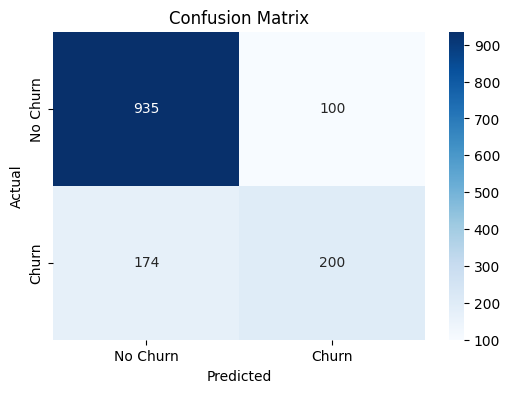

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Calculate Precision, Recall and F1-Score for Churn Class

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("Precision (Churn):", precision)
print("Recall (Churn):", recall)
print("F1-Score (Churn):", f1)

Precision (Churn): 0.6666666666666666
Recall (Churn): 0.5347593582887701
F1-Score (Churn): 0.5934718100890207


The model's precision for churn is 66.67%, meaning that about two-thirds of customers predicted as churners actually churned. The recall is 53.48%, meaning the model identified about half of the customers who actually churned. The F1-score of 59.35% shows a moderate balance between precision and recall. Improving recall would help identify more customers at risk of churn and take retention actions earlier.

## Task 11 — Fix Class Imbalance with SMOTE

In [37]:
# Install imbalanced-learn

%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [38]:
# Check Class Distribution Before SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


### Apply SMOTE to Training Data

In [39]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


### Retrain Logistic Regression with SMOTE

In [40]:
# Train Logistic Regression on SMOTE-balanced Data

smote_model = LogisticRegression(max_iter=5000)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)

print("SMOTE Logistic Regression model trained successfully.")

SMOTE Logistic Regression model trained successfully.


C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluate SMOTE Model

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_smote = precision_score(y_test, y_pred_smote, pos_label=1)
recall_smote = recall_score(y_test, y_pred_smote, pos_label=1)
f1_smote = f1_score(y_test, y_pred_smote, pos_label=1)

print("SMOTE Precision (Churn):", precision_smote)
print("SMOTE Recall (Churn):", recall_smote)
print("SMOTE F1-Score (Churn):", f1_smote)

SMOTE Precision (Churn): 0.5731414868105515
SMOTE Recall (Churn): 0.6390374331550802
SMOTE F1-Score (Churn): 0.6042983565107459


### Before and After SMOTE Comparison

In [42]:
# Compare Model Performance Before and After SMOTE

comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Before SMOTE": [precision, recall, f1],
    "After SMOTE": [precision_smote, recall_smote, f1_smote]
})

print(comparison)

      Metric  Before SMOTE  After SMOTE
0  Precision      0.666667     0.573141
1     Recall      0.534759     0.639037
2   F1-Score      0.593472     0.604298


SMOTE improved the model's recall for churn from 53.48% to 63.90%, helping identify more customers who are likely to churn. The F1-score also improved from 59.35% to 60.43%, showing a better overall balance between precision and recall. Although precision decreased from 66.67% to 57.31%, the improved recall is useful for identifying more at-risk customers.

## Task 12 — Train and Compare Multiple Models

Train Logistic Regression, Random Forest, and XGBoost models using GridSearchCV and compare their Precision, Recall, and F1-Score for the churn class.

In [43]:
# Install XGBoost

%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


### Import Models and GridSearchCV

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Define Hyperparameter Grids

In [45]:
# Define Hyperparameter Grids

lr_params = {
    "C": [0.1, 1]
}

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10]
}

xgb_params = {
    "n_estimators": [100],
    "max_depth": [3, 5],
    "learning_rate": [0.1]
}

print("Hyperparameter grids defined successfully.")

Hyperparameter grids defined successfully.


### Tune Logistic Regression

In [46]:
# Logistic Regression with GridSearchCV

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    lr_params,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

lr_grid.fit(X_train_smote, y_train_smote)

best_lr = lr_grid.best_estimator_

print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print("Best Cross-Validation F1-Score:", lr_grid.best_score_)

Best Logistic Regression Parameters: {'C': 0.1}
Best Cross-Validation F1-Score: 0.7632265644115842


### Tune Random Forest

In [47]:
# Random Forest with GridSearchCV

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_smote, y_train_smote)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Cross-Validation F1-Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': 10, 'n_estimators': 200}
Best Cross-Validation F1-Score: 0.8052375347625187


### Tune XGBoost

In [48]:
# XGBoost with GridSearchCV

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),
    xgb_params,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

xgb_grid.fit(X_train_smote, y_train_smote)

best_xgb = xgb_grid.best_estimator_

print("Best XGBoost Parameters:", xgb_grid.best_params_)
print("Best Cross-Validation F1-Score:", xgb_grid.best_score_)

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation F1-Score: 0.7875275133517406


### Evaluate Tuned Models on Test Data

In [49]:
# Generate predictions on the unchanged test set

y_pred_lr = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

print("Test predictions generated successfully.")

Test predictions generated successfully.


### Compare Model Performance

In [50]:
# Calculate Precision, Recall and F1-Score for Churn Class

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

results = []

for name, predictions in models.items():
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, predictions, pos_label=1),
        "Recall": recall_score(y_test, predictions, pos_label=1),
        "F1-Score": f1_score(y_test, predictions, pos_label=1)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Precision  Recall  F1-Score
0  Logistic Regression     0.5682  0.6684    0.6143
1        Random Forest     0.5441  0.6925    0.6094
2              XGBoost     0.5451  0.6952    0.6110


Logistic Regression achieved the highest test F1-score of 61.43% among the three tuned models, providing the best balance between precision and recall. XGBoost achieved the highest recall at 69.52%, while Random Forest achieved a recall of 69.25%. Based on the F1-score, Logistic Regression is selected as the best-performing model for churn prediction.

## Task 13 — Track Experiments with MLflow

Use MLflow to track the tuned Logistic Regression, Random Forest, and XGBoost models from Task 12 by logging their parameters and churn-class Precision, Recall, and F1-Score.

### Install MLflow

In [51]:
!pip install mlflow

In [52]:
import sys
!{sys.executable} -m pip install mlflow


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [53]:
import mlflow

print("MLflow version:", mlflow.__version__)

C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow version: 3.15.2


### MLflow Experiment Setup

In [54]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment("Customer_Churn_Task_13")

print("MLflow experiment is ready!")

MLflow experiment is ready!


In [55]:
print("X_train_smote:", "X_train_smote" in globals())
print("y_train_smote:", "y_train_smote" in globals())
print("X_test:", "X_test" in globals())
print("y_test:", "y_test" in globals())

X_train_smote: True
y_train_smote: True
X_test: True
y_test: True


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": (best_lr, y_pred_lr),
    "Random Forest": (best_rf, y_pred_rf),
    "XGBoost": (best_xgb, y_pred_xgb)
}

for name, (model, predictions) in models.items():
    with mlflow.start_run(run_name=name):

        mlflow.log_params(model.get_params())

        mlflow.log_metric(
            "precision",
            precision_score(y_test, predictions)
        )

        mlflow.log_metric(
            "recall",
            recall_score(y_test, predictions)
        )

        mlflow.log_metric(
            "f1_score",
            f1_score(y_test, predictions)
        )

        mlflow.set_tag("Task", "Task 13")
        mlflow.set_tag("Model", name)

print("3 model runs logged successfully!")

3 model runs logged successfully!


## Task 14 — Integrate ML Predictions into Power BI

Export the best model's churn predictions and probabilities for each customer, then integrate them into Power BI to build a DAX-powered prediction dashboard.

In [57]:
# Generate churn predictions and probabilities using the best model

best_model = best_lr

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 1409


In [58]:
# Create prediction results for Power BI

prediction_df = pd.DataFrame({
    "CustomerIndex": X_test.index,
    "ChurnPrediction": y_pred,
    "ChurnProbability": y_prob
})

# Add MonthlyCharges from the original cleaned data
prediction_df["MonthlyCharges"] = cleaned_df.loc[X_test.index, "MonthlyCharges"].values

print(prediction_df.head())
print("Prediction table shape:", prediction_df.shape)

   CustomerIndex  ChurnPrediction  ChurnProbability  MonthlyCharges
0            437                0          0.025249      114.050003
1           2280                1          0.697742      100.150002
2           2235                0          0.031661       78.349998
3           4460                0          0.378234       78.199997
4           3761                0          0.015857       82.650002
Prediction table shape: (1409, 4)


In [59]:
# Export predictions for Power BI

prediction_df.to_csv("ChurnPredictions.csv", index=False)

print("ChurnPredictions.csv exported successfully!")

ChurnPredictions.csv exported successfully!


# Task 15 — Explain Your Model's Decisions (LIME / Feature Importance)

In [62]:
# Install LIME in the current Jupyter Python environment
%pip install lime

  Using cached lime-0.2.0.1.tar.gz (275 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 645.7 kB/s eta 0:00:18
   -- ------------------------------------- 0.8/11.9 MB 780.2 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/11.9 MB 898.8 kB/s eta 0:00:13
   ---- -------------------------------


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [63]:
# Import LIME and supporting libraries for model explainability and visualization
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

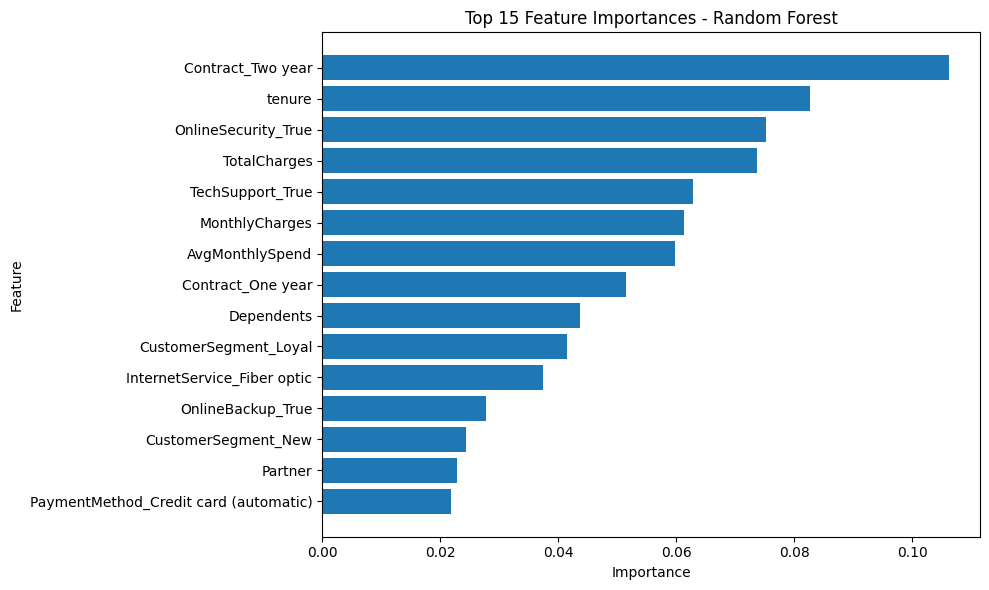

In [64]:
# Calculate and visualize the top features influencing the Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [65]:
# Create a LIME explainer using the training data to explain individual predictions
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Churn", "Churn"],
    mode="classification",
    random_state=42
)

In [66]:
# Select one predicted churn customer and one predicted no-churn customer for LIME explanation
y_pred_best = best_model.predict(X_test)

churn_index = np.where(y_pred_best == 1)[0][0]
no_churn_index = np.where(y_pred_best == 0)[0][0]

print("Churn customer index:", churn_index)
print("No Churn customer index:", no_churn_index)

Churn customer index: 1
No Churn customer index: 0


In [68]:
# Generate and display the LIME explanation for the selected churn customer
churn_explanation = explainer.explain_instance(
    X_test.iloc[churn_index].values,
    lambda x: best_model.predict_proba(
        pd.DataFrame(x, columns=X_train.columns)
    ),
    num_features=10
)

churn_explanation.as_list()

[('MonthlyCharges > 90.00', 0.4976383898347641),
 ('tenure <= 9.00', 0.17637393579177618),
 ('0.00 < InternetService_Fiber optic <= 1.00', -0.1516450892168768),
 ('OnlineSecurity_True <= 0.00', 0.12293900733171961),
 ('Contract_Two year <= 0.00', 0.12036619527182724),
 ('0.00 < TechSupport_True <= 1.00', -0.09856862083606684),
 ('OnlineBackup_True <= 0.00', 0.09511653949919877),
 ('PaymentMethod_Credit card (automatic) > 0.00', -0.08366436437001924),
 ('Contract_One year <= 0.00', 0.08239800265768228),
 ('0.00 < StreamingTV_True <= 1.00', -0.07339186669905448)]

In [69]:
# Generate a LIME explanation for the selected no-churn customer
no_churn_explanation = explainer.explain_instance(
    X_test.iloc[no_churn_index].values,
    lambda x: best_model.predict_proba(
        pd.DataFrame(x, columns=X_train.columns)
    ),
    num_features=10
)

no_churn_explanation.as_list()

[('MonthlyCharges > 90.00', 0.49678468220860267),
 ('tenure > 55.00', -0.20312665038163452),
 ('TotalCharges > 3835.83', 0.1840126545003208),
 ('0.00 < InternetService_Fiber optic <= 1.00', -0.14140562843001853),
 ('Contract_Two year > 0.00', -0.14073069502879915),
 ('0.00 < TechSupport_True <= 1.00', -0.11945036622280367),
 ('0.00 < OnlineSecurity_True <= 1.00', -0.11668314819391948),
 ('Contract_One year <= 0.00', 0.09272750912118091),
 ('0.00 < OnlineBackup_True <= 1.00', -0.08902001895139283),
 ('PaymentMethod_Credit card (automatic) > 0.00', -0.08496216624330505)]

In [70]:
# Translate the LIME explanation into simple business language
business_explanation = """
The LIME explanation shows that this customer's high MonthlyCharges and relatively
low tenure increased the likelihood of churn. The absence of online security also
supported the churn prediction. On the other hand, having a longer-term contract,
technical support, and fiber-related service factors reduced the churn likelihood.
This indicates that pricing and customer tenure are important factors to consider
when identifying customers who may be at risk of leaving.
"""

print(business_explanation)


The LIME explanation shows that this customer's high MonthlyCharges and relatively
low tenure increased the likelihood of churn. The absence of online security also
supported the churn prediction. On the other hand, having a longer-term contract,
technical support, and fiber-related service factors reduced the churn likelihood.
This indicates that pricing and customer tenure are important factors to consider
when identifying customers who may be at risk of leaving.



# Task 16 — Data Validation & Pipeline Robustness

In [74]:
# Define required input fields while excluding the non-predictive customer ID
required_fields = df.drop(columns=["Churn", "customerID"]).columns.tolist()

In [87]:
# Create a robust validation function for new customer churn prediction

def predict_new_customer(customer_data):
    if isinstance(customer_data, dict):
        customer_data = pd.DataFrame([customer_data])
    elif isinstance(customer_data, pd.DataFrame):
        customer_data = customer_data.copy()
    else:
        raise TypeError("Input must be a dictionary or pandas DataFrame.")

    missing_fields = [col for col in required_fields if col not in customer_data.columns]

    if missing_fields:
        raise ValueError(f"Missing required fields: {missing_fields}")

    numeric_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

    for col in numeric_columns:
        if col in customer_data.columns:
            try:
                customer_data[col] = pd.to_numeric(customer_data[col])
            except (ValueError, TypeError):
                raise TypeError(f"{col} must contain numeric values.")

    if (customer_data["tenure"] < 0).any():
        raise ValueError("Tenure cannot be negative.")

    if (customer_data["MonthlyCharges"] < 0).any():
        raise ValueError("MonthlyCharges cannot be negative.")

    if (customer_data["TotalCharges"] < 0).any():
        raise ValueError("TotalCharges cannot be negative.")

    customer_data = customer_data[required_fields]

    customer_data["MultipleLines"] = customer_data["MultipleLines"].fillna("No phone service")

    internet_columns = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]

    for col in internet_columns:
        customer_data[col] = customer_data[col].fillna("No internet service")

    customer_data["AvgMonthlySpend"] = (
        customer_data["TotalCharges"] /
        customer_data["tenure"].replace(0, 1)
    )

    customer_data["CustomerSegment"] = pd.cut(
        customer_data["tenure"],
        bins=[-1, 12, 24, float("inf")],
        labels=["New", "Established", "Loyal"]
    )

    customer_data = pd.get_dummies(
        customer_data,
        drop_first=True,
        dtype=int
    )

    customer_data = customer_data.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    probability = best_model.predict_proba(customer_data)[:, 1][0]

    return probability

In [84]:
# Test the function with a valid new customer input
new_customer = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 75.50,
    "TotalCharges": 906.00
}

churn_probability = predict_new_customer(new_customer)

print(f"Predicted Churn Probability: {churn_probability:.2%}")

Predicted Churn Probability: 99.93%


In [85]:
# Test invalid input with a negative tenure value
bad_customer_1 = new_customer.copy()
bad_customer_1["tenure"] = -5

try:
    predict_new_customer(bad_customer_1)
except ValueError as e:
    print("Validation Error:", e)

Validation Error: Tenure cannot be negative.


In [86]:
# Test invalid input with a missing required field
bad_customer_2 = new_customer.copy()
del bad_customer_2["Contract"]

try:
    predict_new_customer(bad_customer_2)
except ValueError as e:
    print("Validation Error:", e)

Validation Error: Missing required fields: ['Contract']


In [88]:
# Test invalid input with a wrong data type for tenure
bad_customer_3 = new_customer.copy()
bad_customer_3["tenure"] = "twelve"

try:
    predict_new_customer(bad_customer_3)
except TypeError as e:
    print("Validation Error:", e)

Validation Error: tenure must contain numeric values.


### Conclusion

The prediction function successfully validates customer inputs and handles invalid data safely.  
It provides a reliable churn probability for valid customer data.  
Overall, the pipeline is robust and ready for reusable deployment.

# Task 17 — Package Model as a Reusable Pipeline

In [90]:
# Import Pipeline and joblib to package and save the trained model
from sklearn.pipeline import Pipeline
import joblib

In [91]:
# Import FunctionTransformer to include our existing preprocessing inside the pipeline
from sklearn.preprocessing import FunctionTransformer

In [92]:
# Define the preprocessing function used inside the reusable pipeline

def preprocess_for_pipeline(customer_data):
    customer_data = customer_data.copy()

    if "customerID" in customer_data.columns:
        customer_data = customer_data.drop(columns=["customerID"])

    customer_data["MultipleLines"] = customer_data["MultipleLines"].fillna("No phone service")

    internet_columns = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]

    for col in internet_columns:
        customer_data[col] = customer_data[col].fillna("No internet service")

    customer_data["AvgMonthlySpend"] = (
        customer_data["TotalCharges"] /
        customer_data["tenure"].replace(0, 1)
    )

    customer_data["CustomerSegment"] = pd.cut(
        customer_data["tenure"],
        bins=[-1, 12, 24, float("inf")],
        labels=["New", "Established", "Loyal"]
    )

    customer_data = pd.get_dummies(
        customer_data,
        drop_first=True,
        dtype=int
    )

    customer_data = customer_data.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    return customer_data

In [93]:
# Combine preprocessing and the trained Logistic Regression model into one reusable pipeline
churn_pipeline = Pipeline([
    ("preprocessing", FunctionTransformer(preprocess_for_pipeline)),
    ("model", best_model)
])

print("Reusable churn pipeline created successfully.")

Reusable churn pipeline created successfully.


In [94]:
# Save the reusable churn pipeline as a Pickle file for future predictions
joblib.dump(churn_pipeline, "churn_prediction_pipeline.pkl")

print("Pipeline saved successfully as churn_prediction_pipeline.pkl")

Pipeline saved successfully as churn_prediction_pipeline.pkl


In [95]:
# Load the saved pipeline and make a prediction without retraining the model
loaded_pipeline = joblib.load("churn_prediction_pipeline.pkl")

brand_new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 48,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "Yes",
    "DeviceProtection": "Yes",
    "TechSupport": "Yes",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "One year",
    "PaperlessBilling": "No",
    "PaymentMethod": "Bank transfer (automatic)",
    "MonthlyCharges": 60.00,
    "TotalCharges": 2880.00
}])

prediction_probability = loaded_pipeline.predict_proba(brand_new_customer)[0, 1]

print(f"Predicted Churn Probability: {prediction_probability:.2%}")

Predicted Churn Probability: 98.37%


In [96]:
# Verify that the saved pipeline file exists successfully
import os

print("Pipeline file exists:", os.path.exists("churn_prediction_pipeline.pkl"))
print("File size:", os.path.getsize("churn_prediction_pipeline.pkl"), "bytes")

Pipeline file exists: True
File size: 2545 bytes


## Task 17 Conclusion

The churn prediction model was successfully packaged into a reusable pipeline.
The pipeline was saved as a `.pkl` file and loaded successfully without retraining.
A brand-new customer was tested and the pipeline returned a churn probability of 98.37%.